# More Exploring with KDE 

Some Notes:
Without weighting, epsilon is just a Euclidean threshold, so it triggers simplex births earlier in dense regions and later in sparse ones. With weighting, epsilon becomes a density-corrected threshold that should trigger births at roughly the same rate everywhere, regardless of local sampling density.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sample_circle_half_dense(n, p_dense=0.8, seed=None):
    """
    Sample n points on the unit circle, with p_dense fraction in the dense
    half (theta in [0, pi)) and the remainder in the sparse half ([pi, 2pi)).
    """
    rng = np.random.default_rng(seed)

    # Choose which half each point comes from
    dense_mask = rng.random(n) < p_dense

    theta = np.empty(n)

    # Dense half: [0, pi)
    theta[dense_mask] = rng.uniform(0.0, np.pi, dense_mask.sum())

    # Sparse half: [pi, 2pi)
    theta[~dense_mask] = rng.uniform(np.pi, 2 * np.pi, (~dense_mask).sum())

    X = np.column_stack([np.cos(theta), np.sin(theta)])
    return X, theta

def plot_circle_points(X):
    """Plot 2D points sampled on the unit circle."""
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], s=10)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Half-Dense Circle")
    plt.show()


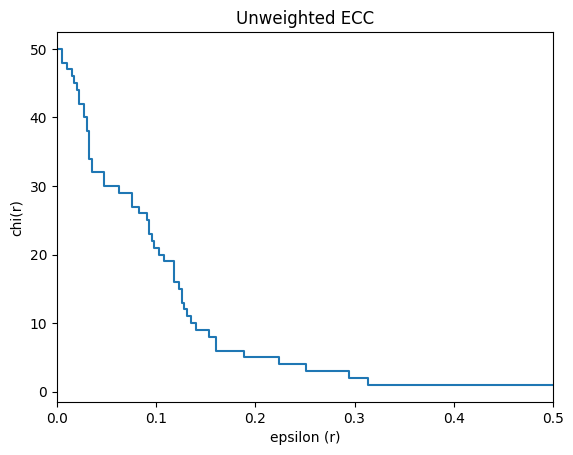

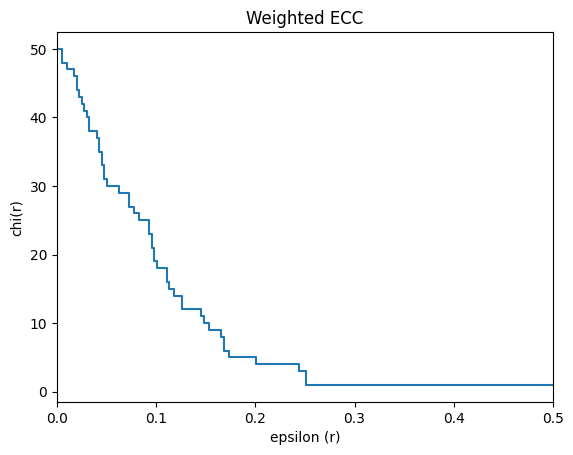

In [2]:
import ecc_vr as vr

X, theta = sample_circle_half_dense(50, p_dense=0.8, seed=0)

Dw, _ = vr.weighted_distance_matrix_kde(X, h=0.15, d_manifold=1, sym_rule="min")

C_raw = vr.local_contributions(X, epsilon=0.5, max_dim=None)          # unweighted, non-uniform
Cw    = vr.local_contributions(X, epsilon=0.5, max_dim=None, D=Dw)    # weighted, same points

vr.plot_ECC_from_C(C_raw, eps_min=0.0, eps_max=0.5, num = 200, title = "Unweighted ECC" )
vr.plot_ECC_from_C(Cw, eps_min=0.0, eps_max=0.5, num = 200, title = "Weighted ECC" )


# Now we wish to compare using a KDE to the real pdf

In both cases, epsilon is rescaled by $2\pi$ so it represents a fraction of the circle's circumference rather than a raw Euclidean distance. Thus, making the two filtrations geometrically comparable. The KDE version approximates this correction from the data alone; the true-density version applies it exactly, so any difference between the two curves reflects the error in the KDE estimate.

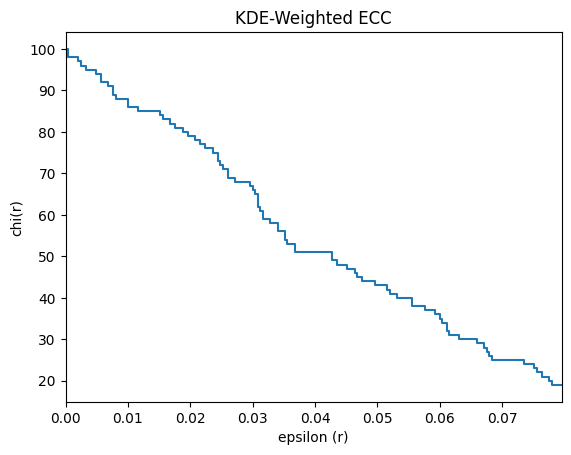

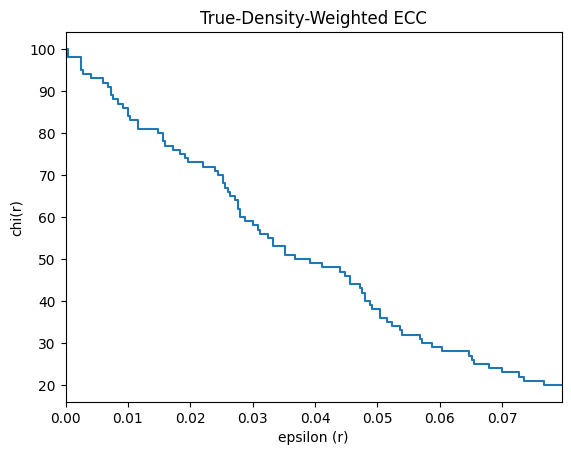

In [ ]:
def true_density_half_dense(theta: np.ndarray, p_dense: float = 0.8) -> np.ndarray:
    """
    True PDF of sample_circle_half_dense evaluated at each angle theta.
    Dense half [0, pi):   p_dense / pi
    Sparse half [pi, 2pi): (1 - p_dense) / pi
    """
    f = np.where(theta < np.pi, p_dense / np.pi, (1 - p_dense) / np.pi)
    return f


def weighted_distance_matrix_f(X, f, d_manifold=1, sym_rule="min"):
    """
    Like weighted_distance_matrix, but accepts a precomputed density array f
    instead of estimating it via KDE. f is mean-normalized internally.
    """
    X = np.asarray(X, dtype=float)
    D = vr.pairwise_dist(X)

    f = np.maximum(f, 1e-12)
    f = f / f.mean()
    s = f ** (1.0 / d_manifold)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (2.0 * si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w


# comparison
p_dense = 0.8
X, theta = sample_circle_half_dense(100, p_dense=p_dense, seed=0)

# KDE-weighted
Dw_kde, _ = vr.weighted_distance_matrix_kde(X, h=0.15, d_manifold=1, sym_rule="min")

# True-density-weighted
f_true = true_density_half_dense(theta, p_dense=p_dense)
Dw_true = weighted_distance_matrix_f(X, f_true, d_manifold=1, sym_rule="min")

eps_raw = 0.5
eps = eps_raw / (2 * np.pi)   # rescale so epsilon is in units of fraction-of-circle

C_kde  = vr.local_contributions(X, epsilon=eps, max_dim=None, D=Dw_kde)
C_true = vr.local_contributions(X, epsilon=eps, max_dim=None, D=Dw_true)

vr.plot_ECC_from_C(C_kde,  eps_min=0.0, eps_max=eps, num=200, title="KDE-Weighted ECC", xlabel= "Normalized Epsilon")
vr.plot_ECC_from_C(C_true, eps_min=0.0, eps_max=eps, num=200, title="True-Density-Weighted ECC", xlabel= "Normalized Epsilon")

The two curves are nearly identical in shape! They both start at chi=100 and decline at roughly the same rate to ~20 by $\varepsilon = 0.8$.This means the KDE is doing a good job approximating the true density in this example. The small differences are visible in the step pattern. 